# Greenhouse Gas Emissions Forecasting: LSTM Models
## CO2, CH4, and N2O — Global Total Forecasting

This notebook builds LSTM (Long Short-Term Memory) deep learning models to forecast global greenhouse gas emissions, for direct comparison against the SARIMA models built previously.

**Gases covered:** CO2, CH4, N2O
**Level:** Global total (summed across all countries and sectors)
**Split:** 80/20 chronological train-test split (matching SARIMA)
**Metrics:** MAE, RMSE, MAPE
**Lookback window:** 3 years (informed by ACF analysis — strong dependency at lag 1-3)

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)
np.random.seed(42)

I0000 00:00:1781593536.840541     532 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781593536.844901     532 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781593553.664756     532 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1781593563.559241     532 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781593563.562289     532 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## 1. Data Loading & Global Aggregation

Each gas dataset is in EDGAR wide-format (countries as rows, years 1970-2018 as columns). We replicate the exact cleaning and aggregation pipeline used in the SARIMA notebook, then sum across all countries/sectors to get a single global yearly total per gas.

In [2]:
def load_global_ts(path):
    df = pd.read_csv(path, skiprows=9)
    df = df.loc[:, ~df.columns.str.contains("^Unnamed")]
    df = df.drop_duplicates()
    df = df.dropna(how="all")
    df = df.dropna(subset=["Name", "Country_code_A3"])
    year_cols = [c for c in df.columns if c.startswith("Y_")]
    df = df.dropna(subset=year_cols, thresh=int(0.7 * len(year_cols)))
    df[year_cols] = df[year_cols].astype(float)
    df_long = df.melt(id_vars=["Name", "Country_code_A3"], value_vars=year_cols,
                       var_name="Year", value_name="Emissions")
    df_long["Year"] = df_long["Year"].str.replace("Y_", "").astype(int)
    ts = df_long.groupby("Year")["Emissions"].sum()
    return ts

co2_ts = load_global_ts("data_co2.csv")
ch4_ts = load_global_ts("data_ch4.csv")
n2o_ts = load_global_ts("data_n2o.csv")

print("CO2:", co2_ts.shape, "| CH4:", ch4_ts.shape, "| N2O:", n2o_ts.shape)

CO2: (49,) | CH4: (49,) | N2O: (49,)


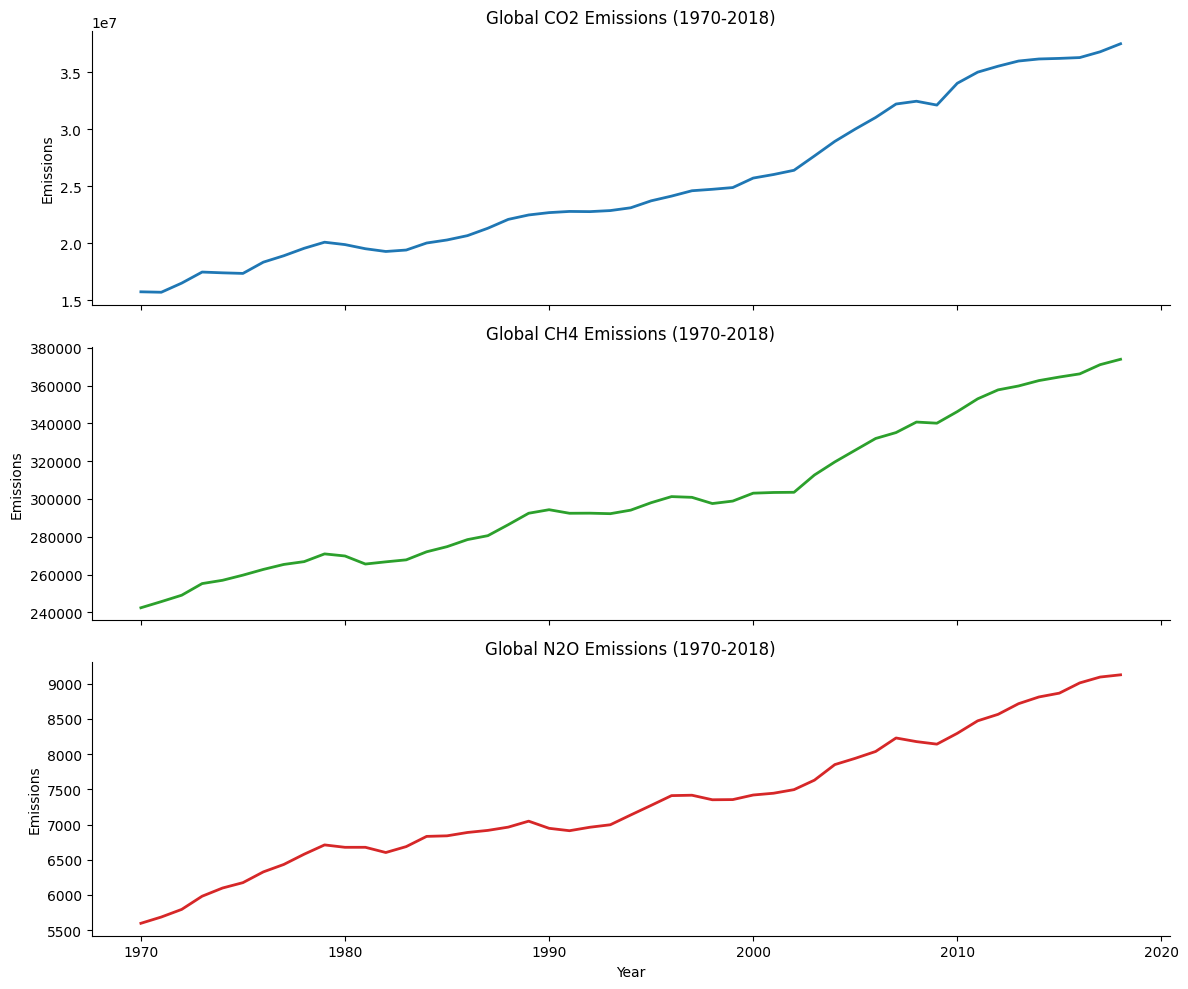

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

for ax, ts, name, color in zip(axes, [co2_ts, ch4_ts, n2o_ts],
                                 ["CO2", "CH4", "N2O"],
                                 ["#1f77b4", "#2ca02c", "#d62728"]):
    ax.plot(ts.index, ts.values, linewidth=2, color=color)
    ax.set_title(f"Global {name} Emissions (1970-2018)")
    ax.set_ylabel("Emissions")
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[-1].set_xlabel("Year")
plt.tight_layout()
plt.show()

## 2. LSTM Pipeline Function

A reusable function builds, trains, and evaluates an LSTM for any gas series:

1. **80/20 chronological split** (matching SARIMA, no shuffling — preserves temporal order)
2. **MinMax scaling** fit only on train data to avoid leakage
3. **Windowing** with a 3-year lookback (matches ACF lag 1-3 dependency from SARIMA analysis)
4. **2-layer stacked LSTM** with dropout for regularization (small dataset, 49 points)
5. **Early stopping** to prevent overfitting
6. **Evaluation** on MAE, RMSE, MAPE — inverse-transformed back to original scale

In [4]:
def build_and_evaluate_lstm(ts, gas_name, lookback=3, epochs=200, batch_size=4, verbose=0):
    # Train-test split (80/20, chronological)
    train_size = int(len(ts) * 0.8)
    train_raw, test_raw = ts[:train_size], ts[train_size:]

    # Scale (fit on train only)
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaler.fit(train_raw.values.reshape(-1, 1))
    full_scaled = scaler.transform(ts.values.reshape(-1, 1))

    # Create windowed sequences
    def create_sequences(data, lookback):
        X, y = [], []
        for i in range(lookback, len(data)):
            X.append(data[i-lookback:i, 0])
            y.append(data[i, 0])
        return np.array(X), np.array(y)

    X_all, y_all = create_sequences(full_scaled, lookback)

    split_point = train_size - lookback
    X_train, y_train = X_all[:split_point], y_all[:split_point]
    X_test,  y_test  = X_all[split_point:], y_all[split_point:]

    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_test  = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

    # Build model
    model = Sequential([
        LSTM(64, activation="tanh", return_sequences=True, input_shape=(lookback, 1)),
        Dropout(0.2),
        LSTM(32, activation="tanh"),
        Dropout(0.2),
        Dense(16, activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")

    early_stop = EarlyStopping(monitor="loss", patience=20, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        verbose=verbose,
        callbacks=[early_stop]
    )

    # Predict & inverse transform
    pred_scaled = model.predict(X_test, verbose=0)
    pred   = scaler.inverse_transform(pred_scaled).flatten()
    actual = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

    # Metrics
    mae  = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mape = np.mean(np.abs((actual - pred) / actual)) * 100

    test_years = ts.index[train_size:]

    results = {
        "gas": gas_name,
        "model": model,
        "scaler": scaler,
        "history": history,
        "test_years": test_years,
        "actual": actual,
        "pred": pred,
        "mae": mae,
        "rmse": rmse,
        "mape": mape,
        "train_raw": train_raw,
        "test_raw": test_raw
    }

    print(f"===== LSTM EVALUATION: {gas_name} =====")
    print(f"MAE  : {mae:,.2f}")
    print(f"RMSE : {rmse:,.2f}")
    print(f"MAPE : {mape:.2f} %\n")

    return results

## 3. Train LSTM for Each Gas

In [5]:
co2_results = build_and_evaluate_lstm(co2_ts, "CO2")

E0000 00:00:1781593566.063731     532 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


===== LSTM EVALUATION: CO2 =====
MAE  : 2,512,094.18
RMSE : 2,870,791.34
MAPE : 6.98 %



In [6]:
ch4_results = build_and_evaluate_lstm(ch4_ts, "CH4")

===== LSTM EVALUATION: CH4 =====
MAE  : 7,475.28
RMSE : 9,167.60
MAPE : 2.05 %



In [7]:
n2o_results = build_and_evaluate_lstm(n2o_ts, "N2O")

===== LSTM EVALUATION: N2O =====
MAE  : 146.25
RMSE : 176.39
MAPE : 1.68 %



## 4. Visualization: Actual vs Predicted (per gas)

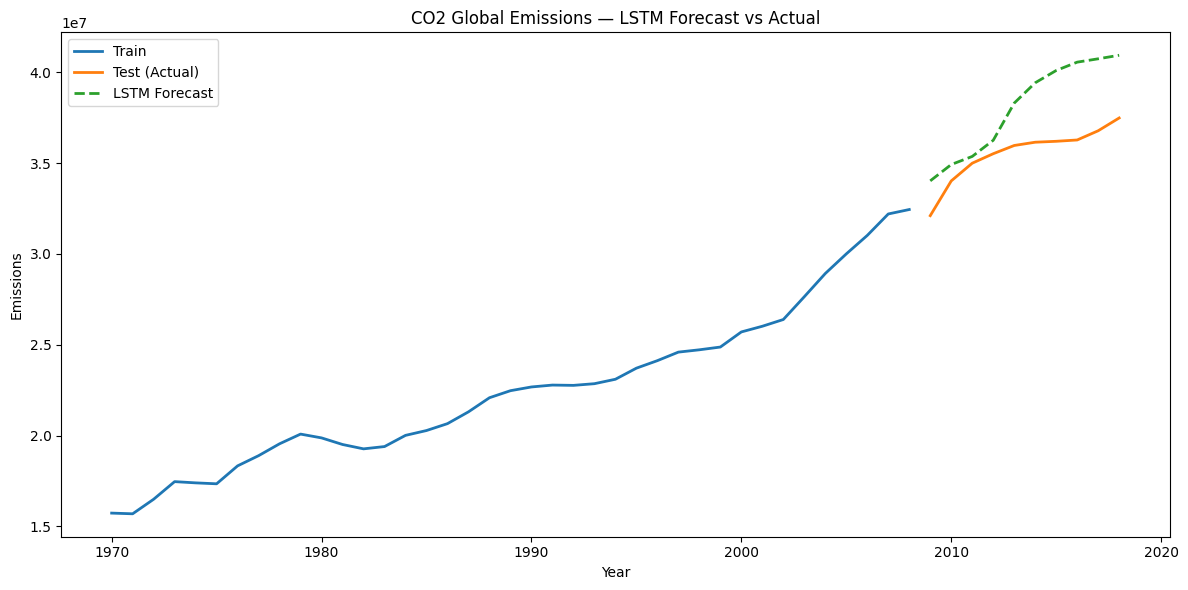

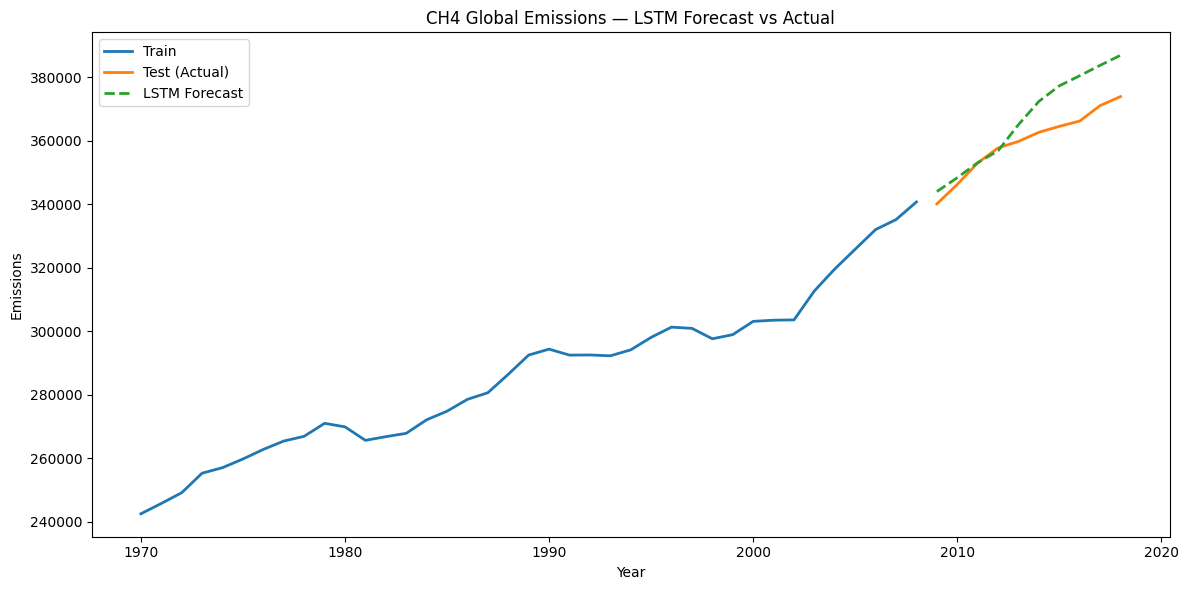

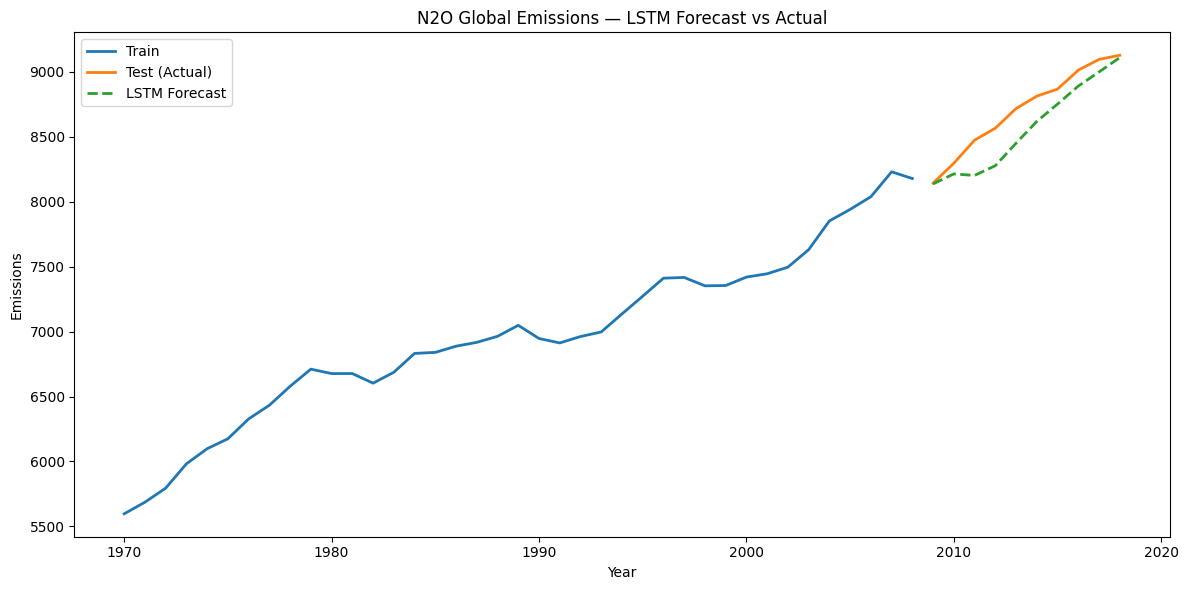

In [8]:
def plot_forecast(results):
    plt.figure(figsize=(12, 6))
    plt.plot(results["train_raw"].index, results["train_raw"].values,
              label="Train", linewidth=2)
    plt.plot(results["test_years"], results["actual"],
              label="Test (Actual)", linewidth=2)
    plt.plot(results["test_years"], results["pred"],
              label="LSTM Forecast", linewidth=2, linestyle="--")
    plt.title(f"{results['gas']} Global Emissions — LSTM Forecast vs Actual")
    plt.xlabel("Year")
    plt.ylabel("Emissions")
    plt.legend()
    plt.grid(False)
    plt.tight_layout()
    plt.show()

plot_forecast(co2_results)
plot_forecast(ch4_results)
plot_forecast(n2o_results)

## 5. Training Loss Curves

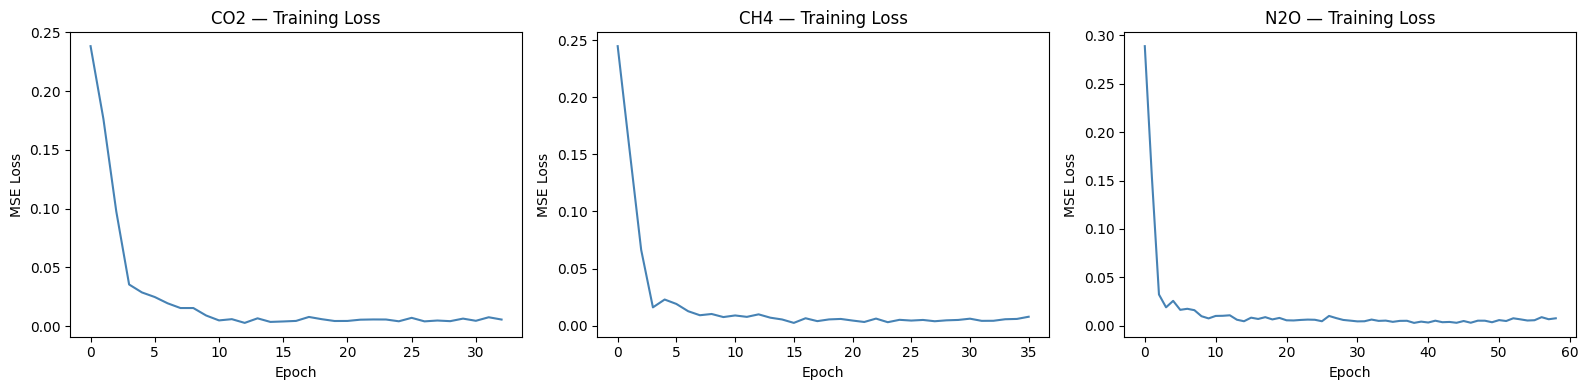

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, results in zip(axes, [co2_results, ch4_results, n2o_results]):
    ax.plot(results["history"].history["loss"], color="steelblue")
    ax.set_title(f"{results['gas']} — Training Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE Loss")
    ax.grid(False)
plt.tight_layout()
plt.show()

## 6. Global-Level SARIMA Baseline

To make a fair comparison, SARIMA is also fit on the **global totals** (not just Canada, as in the original SARIMA notebook) using the same order `(3,1,3)(1,0,1,5)` and the same 80/20 chronological split.

In [10]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

def run_sarima_global(ts, gas_name, order=(3,1,3), seasonal_order=(1,0,1,5)):
    train_size = int(len(ts) * 0.8)
    train, test = ts[:train_size], ts[train_size:]

    model = SARIMAX(train.values, order=order, seasonal_order=seasonal_order,
                     enforce_stationarity=False, enforce_invertibility=False)
    fit = model.fit(disp=False)
    forecast = fit.forecast(steps=len(test))

    test_vals = test.values
    forecast_vals = np.asarray(forecast)

    mae  = mean_absolute_error(test_vals, forecast_vals)
    rmse = np.sqrt(mean_squared_error(test_vals, forecast_vals))
    mape = np.mean(np.abs((test_vals - forecast_vals) / test_vals)) * 100

    print(f"===== SARIMA EVALUATION: {gas_name} (Global) =====")
    print(f"MAE  : {mae:,.2f}")
    print(f"RMSE : {rmse:,.2f}")
    print(f"MAPE : {mape:.2f} %\n")

    return {"mae": mae, "rmse": rmse, "mape": mape, "test": test, "forecast": forecast_vals}

co2_sarima = run_sarima_global(co2_ts, "CO2")
ch4_sarima = run_sarima_global(ch4_ts, "CH4")
n2o_sarima = run_sarima_global(n2o_ts, "N2O")

===== SARIMA EVALUATION: CO2 (Global) =====
MAE  : 3,829,446.85
RMSE : 4,184,109.22
MAPE : 10.59 %

===== SARIMA EVALUATION: CH4 (Global) =====
MAE  : 8,234.24
RMSE : 9,458.19
MAPE : 2.26 %



===== SARIMA EVALUATION: N2O (Global) =====
MAE  : 645.47
RMSE : 731.80
MAPE : 7.27 %



/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## 7. SARIMA vs LSTM Comparison Table

Metrics are pulled directly from the global-level SARIMA run above and the LSTM results from Section 3.

In [11]:
sarima_metrics = {
    "CO2": {"MAE": co2_sarima["mae"], "RMSE": co2_sarima["rmse"], "MAPE": co2_sarima["mape"]},
    "CH4": {"MAE": ch4_sarima["mae"], "RMSE": ch4_sarima["rmse"], "MAPE": ch4_sarima["mape"]},
    "N2O": {"MAE": n2o_sarima["mae"], "RMSE": n2o_sarima["rmse"], "MAPE": n2o_sarima["mape"]},
}

lstm_metrics = {
    "CO2": {"MAE": co2_results["mae"], "RMSE": co2_results["rmse"], "MAPE": co2_results["mape"]},
    "CH4": {"MAE": ch4_results["mae"], "RMSE": ch4_results["rmse"], "MAPE": ch4_results["mape"]},
    "N2O": {"MAE": n2o_results["mae"], "RMSE": n2o_results["rmse"], "MAPE": n2o_results["mape"]},
}

comparison_rows = []
for gas in ["CO2", "CH4", "N2O"]:
    comparison_rows.append({
        "Gas": gas, "Model": "SARIMA",
        "MAE": sarima_metrics[gas]["MAE"],
        "RMSE": sarima_metrics[gas]["RMSE"],
        "MAPE": sarima_metrics[gas]["MAPE"]
    })
    comparison_rows.append({
        "Gas": gas, "Model": "LSTM",
        "MAE": lstm_metrics[gas]["MAE"],
        "RMSE": lstm_metrics[gas]["RMSE"],
        "MAPE": lstm_metrics[gas]["MAPE"]
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df

,Gas,Model,MAE,RMSE,MAPE
0,CO2,SARIMA,3.829447e+06,4.184109e+06,10.590818
1,CO2,LSTM,2.512094e+06,2.870791e+06,6.984436
2,CH4,SARIMA,8.234241e+03,9.458186e+03,2.260678
3,CH4,LSTM,7.475276e+03,9.167595e+03,2.048560
4,N2O,SARIMA,6.454663e+02,7.318017e+02,7.272368
5,N2O,LSTM,1.462467e+02,1.763945e+02,1.682867


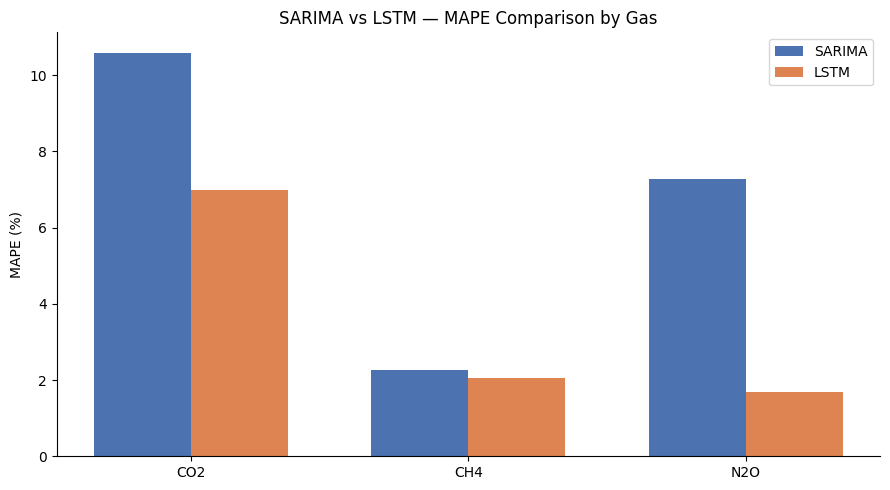

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
gases = ["CO2", "CH4", "N2O"]
sarima_mape = [sarima_metrics[g]["MAPE"] for g in gases]
lstm_mape   = [lstm_metrics[g]["MAPE"] for g in gases]

x = np.arange(len(gases))
width = 0.35

ax.bar(x - width/2, sarima_mape, width, label="SARIMA", color="#4C72B0")
ax.bar(x + width/2, lstm_mape, width, label="LSTM", color="#DD8452")

ax.set_xticks(x)
ax.set_xticklabels(gases)
ax.set_ylabel("MAPE (%)")
ax.set_title("SARIMA vs LSTM — MAPE Comparison by Gas")
ax.legend()
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## 9. Export Trained Models & Scalers

Each LSTM model is saved in the native Keras format (`.keras`), and each fitted `MinMaxScaler` is saved with `joblib` as a `.pkl` file. The scaler must be saved alongside the model — at inference time, new input data has to be scaled with the *same* scaler used during training, then the model's prediction has to be inverse-transformed back to real emissions units using that same scaler.

In [13]:
import joblib

# Save each LSTM model (Keras native format)
co2_results["model"].save("lstm_co2_model.keras")
ch4_results["model"].save("lstm_ch4_model.keras")
n2o_results["model"].save("lstm_n2o_model.keras")

# Save each fitted scaler (pkl, via joblib)
joblib.dump(co2_results["scaler"], "scaler_co2.pkl")
joblib.dump(ch4_results["scaler"], "scaler_ch4.pkl")
joblib.dump(n2o_results["scaler"], "scaler_n2o.pkl")

print("Saved: lstm_co2_model.keras, lstm_ch4_model.keras, lstm_n2o_model.keras")
print("Saved: scaler_co2.pkl, scaler_ch4.pkl, scaler_n2o.pkl")

Saved: lstm_co2_model.keras, lstm_ch4_model.keras, lstm_n2o_model.keras
Saved: scaler_co2.pkl, scaler_ch4.pkl, scaler_n2o.pkl


### Download (if running in Google Colab)

Run the cell below only if you're in Colab and want the files downloaded to your computer.

In [14]:
try:
    from google.colab import files
    for fname in [
        "lstm_co2_model.keras", "lstm_ch4_model.keras", "lstm_n2o_model.keras",
        "scaler_co2.pkl", "scaler_ch4.pkl", "scaler_n2o.pkl"
    ]:
        files.download(fname)
except ImportError:
    print("Not running in Colab — files are saved locally in the working directory.")

Not running in Colab — files are saved locally in the working directory.


### How to Reload for Inference

This is the pattern you'd use in a deployment script (e.g. a Streamlit app) to load the saved artifacts and make a new prediction. `FEATURE_WINDOW` must match the `lookback` used during training (3, in this notebook).

In [15]:
from tensorflow.keras.models import load_model
import joblib
import numpy as np

FEATURE_WINDOW = 3  # must match the lookback used during training

def load_artifacts(gas_name):
    model  = load_model(f"lstm_{gas_name}_model.keras")
    scaler = joblib.load(f"scaler_{gas_name}.pkl")
    return model, scaler

def predict_next_year(model, scaler, last_n_years_values):
    """
    last_n_years_values: list/array of the most recent FEATURE_WINDOW
                          emissions values, in chronological order.
    Returns the predicted next-year emissions value (original scale).
    """
    arr = np.array(last_n_years_values).reshape(-1, 1)
    scaled = scaler.transform(arr)
    X = scaled.reshape((1, FEATURE_WINDOW, 1))
    pred_scaled = model.predict(X, verbose=0)
    pred = scaler.inverse_transform(pred_scaled)
    return float(pred[0, 0])

# Example usage:
# model, scaler = load_artifacts("co2")
# last_3_years = co2_ts.values[-FEATURE_WINDOW:]
# next_year_pred = predict_next_year(model, scaler, last_3_years)
# print(next_year_pred)

## 10. Conclusion

This notebook trained LSTM models on global totals for CO2, CH4, and N2O emissions using a 3-year lookback window and 80/20 chronological split, mirroring the SARIMA setup for direct comparability. Update the SARIMA metrics table above with your global-level results to complete the comparison.

**Key considerations:**
- With only 49 yearly data points per gas, the LSTM operates on a small dataset — dropout and early stopping were used to mitigate overfitting.
- A 3-year lookback aligns with the ACF analysis (significant autocorrelation at lag 1-3, decaying by lag 5).
- SARIMA explicitly models trend/seasonality with statistical structure, while LSTM learns nonlinear patterns implicitly — useful to discuss in your write-up which gas (if any) favors one approach over the other.